c:\Users\digit\miniconda3\envs\infra_quant\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


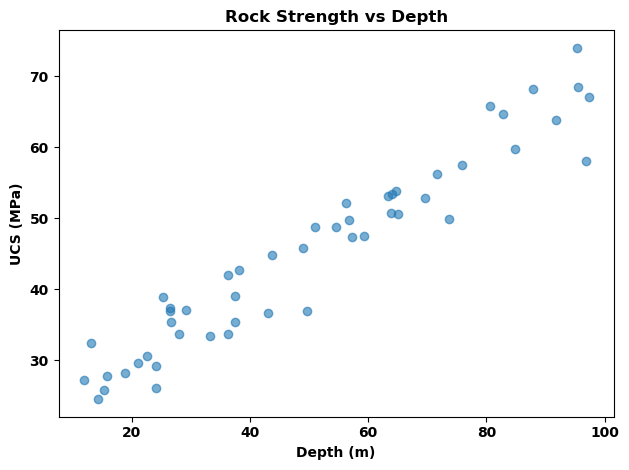

In [1]:
import pymc as pm
import arviz as az
import numpy as np
import matplotlib.pyplot as plt

# i am god

np.random.seed(42)
TRUE_SLOPE = 0.5       # MPa per meter of depth
TRUE_INTERCEPT = 20.0  # MPa at surface
TRUE_SIGMA = 4.0       # Measurement noise but not saying due to sensor error

# saying that inherent variation of nature prevents perfect measurement
# aleatoric uncertainity

n = 50
depth = np.random.uniform(10, 100, n)

ucs = TRUE_INTERCEPT + TRUE_SLOPE * depth + np.random.normal(0, TRUE_SIGMA, n)

plt.scatter(depth, ucs, alpha=0.6)
plt.xlabel("Depth (m)")
plt.ylabel("UCS (MPa)")
plt.title("Rock Strength vs Depth")
plt.tight_layout()
plt.show()


In [2]:
# simple model

with pm.Model() as regression_model:

    # prior: how does the ucs vary with depth; weakly informative, we expect positive (overburden)

    slope = pm.HalfNormal("slope", sigma=1)
    intercept=pm.Lognormal("intercept", mu = np.log(25), sigma=0.55)

# for mu we can cuz its addititive -> multiplicative; center shifting
# sigma!= np.log(15) as it acts as an exponential multiplier
# 0.1 is tight, 0.3 is moderate, and 0.5 to 1.0 is extremely wide/uncertain.
# e^sigma times differ from mu

    sigma = pm.HalfNormal("sigma", sigma = 0.5)
    # value in mind, depending on distro we use on y



    exp_ucs = pm.Deterministic("exp_ucs", intercept+slope*depth)
    # what happens if i dont specify pm.det and only say mu = ... ?

    y = pm.Lognormal("y", mu=pm.math.log(exp_ucs), sigma=sigma, observed=ucs)

    # pm.math to keep with the blueprint vibes, np demands numbers RN



Sampling: [intercept, sigma, slope, y]


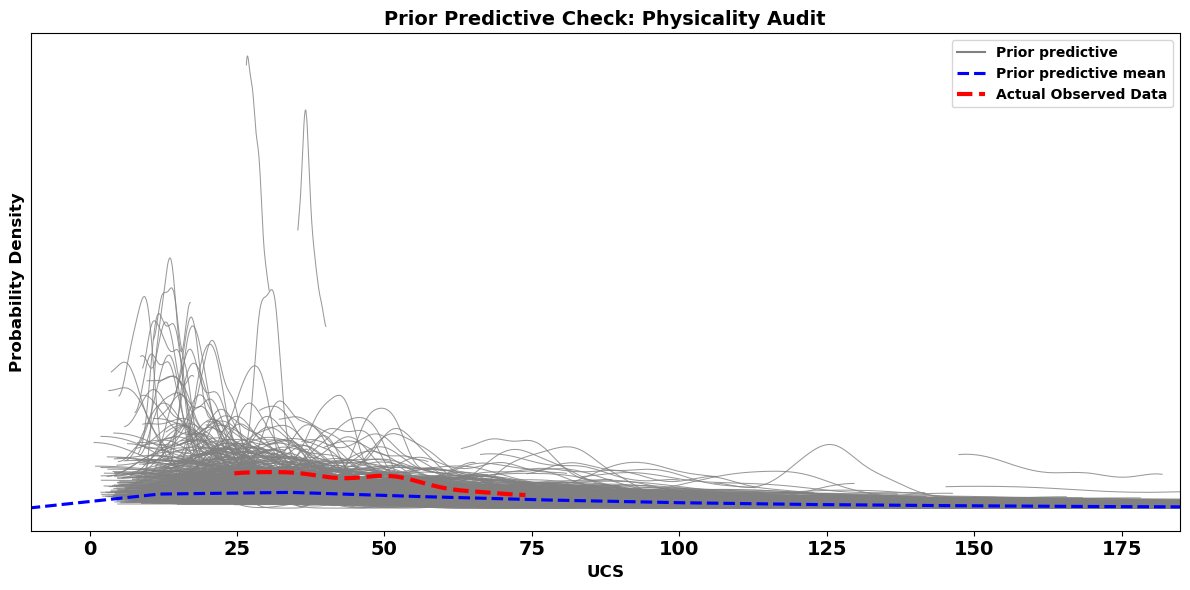

In [3]:
# perform prior predictive checks

with regression_model:
    prior_checks = pm.sample_prior_predictive(samples=1000, random_seed=42)


fig, ax = plt.subplots(figsize=(12, 6))
az.plot_ppc(prior_checks,
group="prior",
kind="kde",
ax=ax,
colors=['gray', 'black', 'blue'], alpha=0.8) # [Prior, Mean, Observed]


az.plot_kde(ucs, ax=ax, plot_kwargs={"color": "red", "linewidth": 3, "linestyle": "--"}, label="Actual Observed Data")

ax.set_title("Prior Predictive Check: Physicality Audit", fontsize=14, fontweight='bold')
ax.set_xlabel("UCS", fontsize=12)
ax.set_ylabel("Probability Density", fontsize=12)


ax.set_xlim(-10, max(ucs) * 2.5)

ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

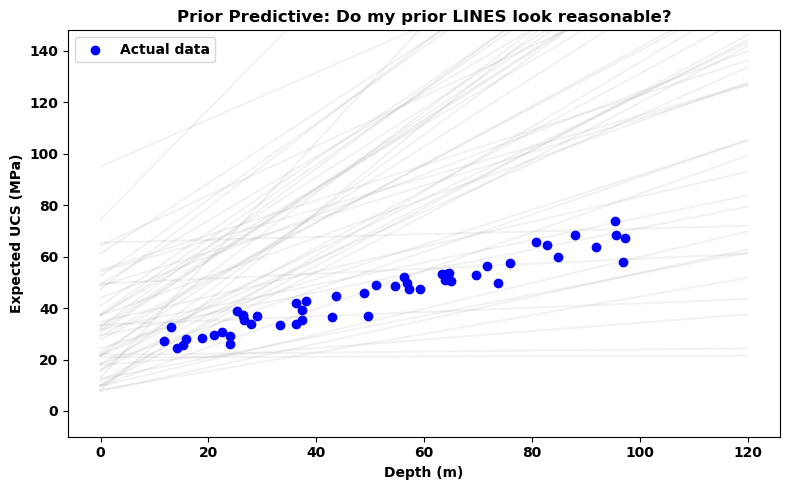

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
x_plot = np.linspace(0, 120, 100)

# Extract prior samples for slope and intercept
prior_slopes = prior_checks.prior["slope"].values.flatten()
prior_intercepts = prior_checks.prior["intercept"].values.flatten()


for i in range(50):
    y_line = prior_intercepts[i] + prior_slopes[i] * x_plot
    ax.plot(x_plot, y_line, 'gray', alpha=0.1)

ax.scatter(depth, ucs, c='blue', zorder=5, label='Actual data')

ax.set_xlabel("Depth (m)")
ax.set_ylabel("Expected UCS (MPa)")
ax.set_title("Prior Predictive: Do my prior LINES look reasonable?")

# Constrain the Y-axis so extreme priors don't ruin the scale
ax.set_ylim(-10, max(ucs) * 2)

ax.legend()
plt.tight_layout()
plt.show()

c:\Users\digit\miniconda3\envs\infra_quant\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [slope, intercept, sigma]
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 27 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


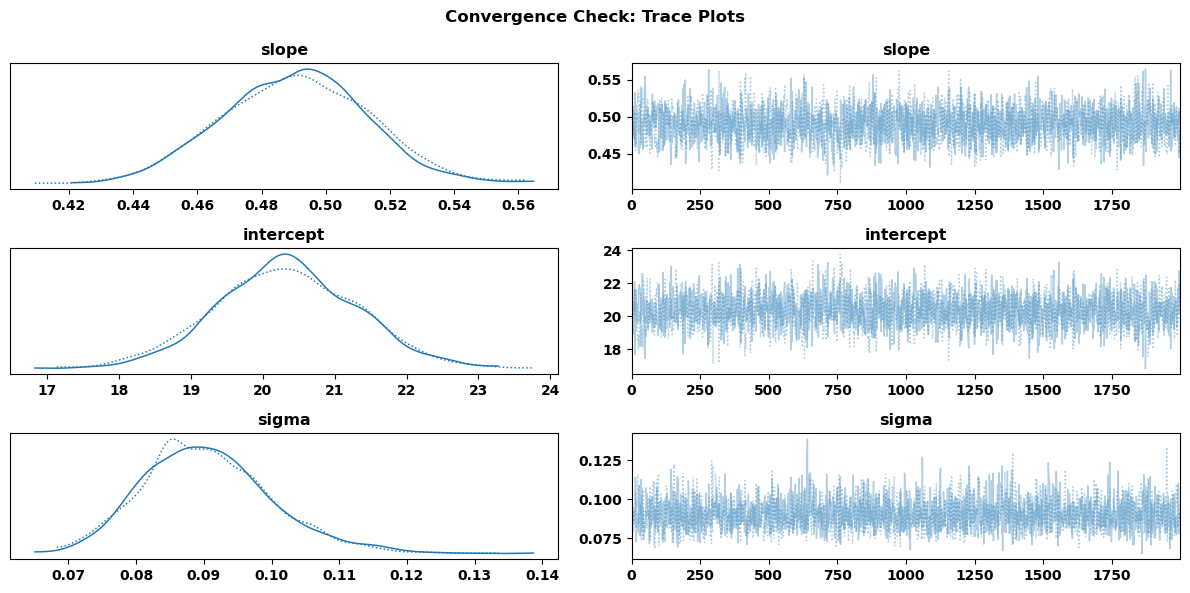

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
slope       0.490  0.023   0.449    0.532      0.001    0.000    2018.0   
intercept  20.329  0.973  18.473   22.127      0.022    0.017    2001.0   
sigma       0.091  0.010   0.073    0.108      0.000    0.000    2440.0   

           ess_tail  r_hat  
slope        1968.0    1.0  
intercept    2149.0    1.0  
sigma        2014.0    1.0  


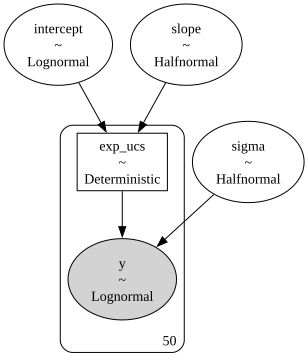

In [5]:
with regression_model:
    trace = pm.sample(2000, tune=1000, chains = 2, cores=2, random_seed=42, progressbar=False)



az.plot_trace(trace, var_names=["slope", "intercept", "sigma"],
              compact=True,
              kind="trace")
plt.suptitle("Convergence Check: Trace Plots")
plt.tight_layout()
plt.show()

print(az.summary(trace, var_names=["slope", "intercept", "sigma"]))

display(pm.model_to_graphviz(regression_model))

Sampling: [y]
C:\Users\digit\AppData\Local\Temp\ipykernel_12512\4204062710.py:7: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\digit\miniconda3\envs\infra_quant\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


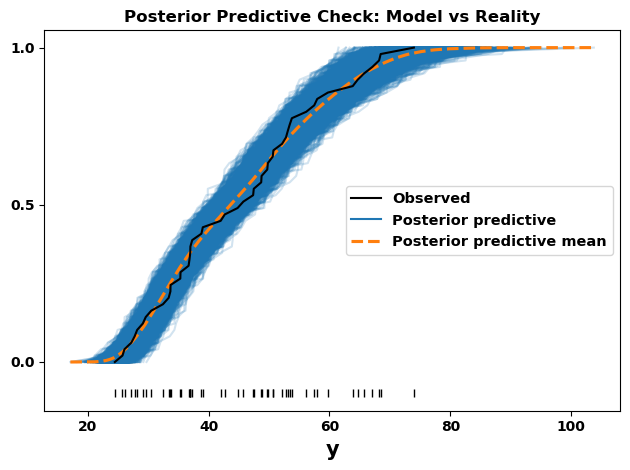

In [6]:
with regression_model:
    ppc = pm.sample_posterior_predictive(trace, random_seed=42, progressbar=False)


az.plot_ppc(ppc, observed_rug=True, kind="cumulative")
plt.title("Posterior Predictive Check: Model vs Reality")
plt.tight_layout()
plt.show()

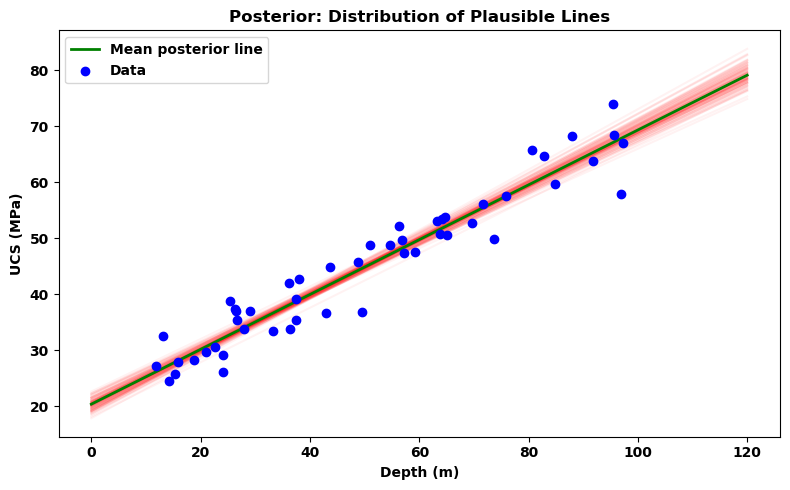

True slope: 0.5, Estimated: 0.490
True intercept: 20.0, Estimated: 20.329


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

# Extract posterior samples
post_slopes = trace.posterior["slope"].values.flatten()
# flattening the (2,2000) dimension
post_intercepts = trace.posterior["intercept"].values.flatten()

for i in range(0, len(post_slopes), len(post_slopes) // 100): # modulo filter here, since 100 lines plottting
    y_line = post_intercepts[i] + post_slopes[i] * x_plot
    ax.plot(x_plot, y_line, 'red', alpha=0.05)

# The MEAN line
mean_slope = post_slopes.mean()
mean_intercept = post_intercepts.mean()
ax.plot(x_plot, mean_intercept + mean_slope * x_plot, 'g-', linewidth=2, label='Mean posterior line')

ax.scatter(depth, ucs, c='blue', zorder=5, label='Data')
ax.set_xlabel("Depth (m)")
ax.set_ylabel("UCS (MPa)")
ax.set_title("Posterior: Distribution of Plausible Lines")
ax.legend()
plt.tight_layout()
plt.show()

print(f"True slope: {TRUE_SLOPE}, Estimated: {mean_slope:.3f}")
print(f"True intercept: {TRUE_INTERCEPT}, Estimated: {mean_intercept:.3f}")

In [8]:
from sklearn.linear_model import LinearRegression

# Frequentist fit
lr = LinearRegression().fit(depth.reshape(-1, 1), ucs)
print(f"Scikit-learn: slope={lr.coef_[0]:.3f}, intercept={lr.intercept_:.3f}")
print(f"PyMC Mean:    slope={mean_slope:.3f}, intercept={mean_intercept:.3f}")
print(f"PyMC 94% HDI: slope={az.hdi(trace, var_names=['slope']).to_dataframe().values}")

# for 'perfect' synth data, they do converge but to estimate our actual ignorance pymc is king


Scikit-learn: slope=0.490, intercept=20.486
PyMC Mean:    slope=0.490, intercept=20.329
PyMC 94% HDI: slope=[[0.44880426]
 [0.53192296]]


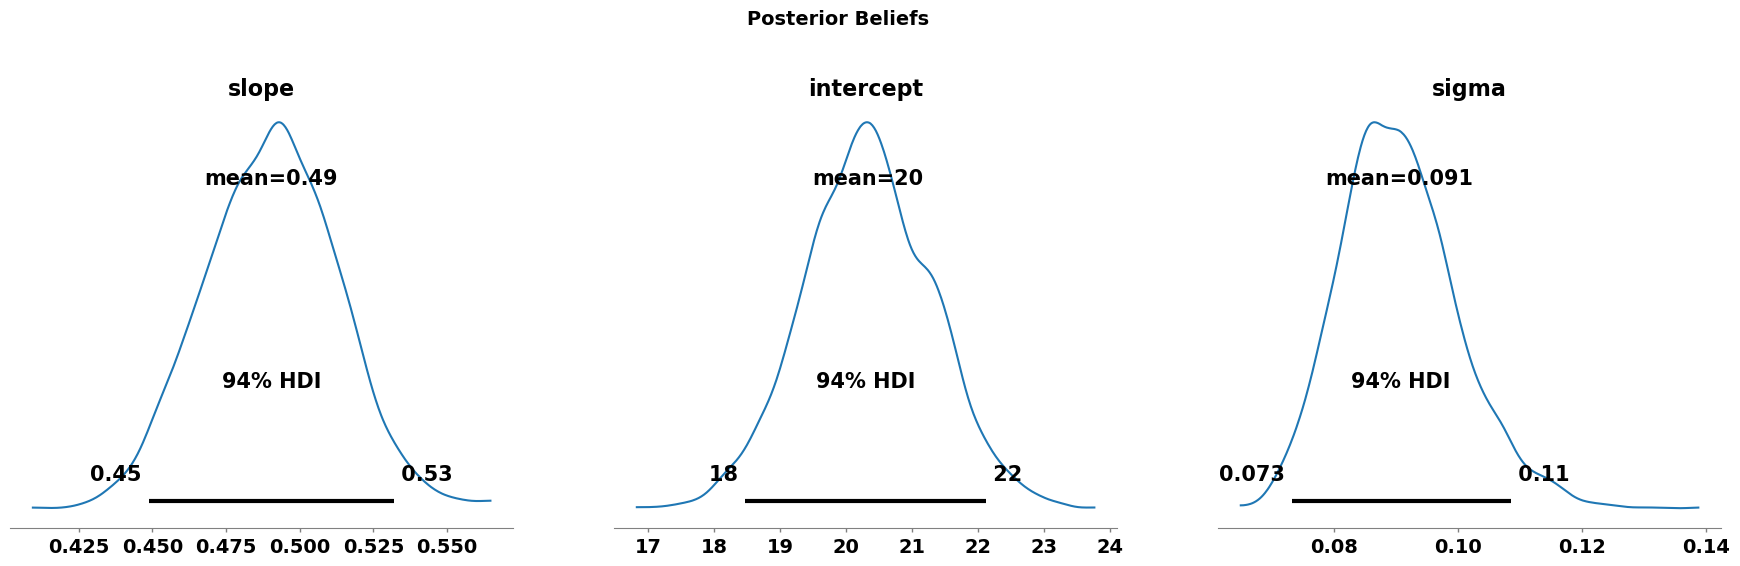

In [9]:
# The Posterior Presentation Graph
az.plot_posterior(trace, var_names=["slope", "intercept", "sigma"], hdi_prob=0.94)
plt.suptitle("Posterior Beliefs", y=1.05, fontsize=14)
plt.show()

c:\Users\digit\miniconda3\envs\infra_quant\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [slope, intercept, sigma]
Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 22 seconds.
There were 143 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some paramet

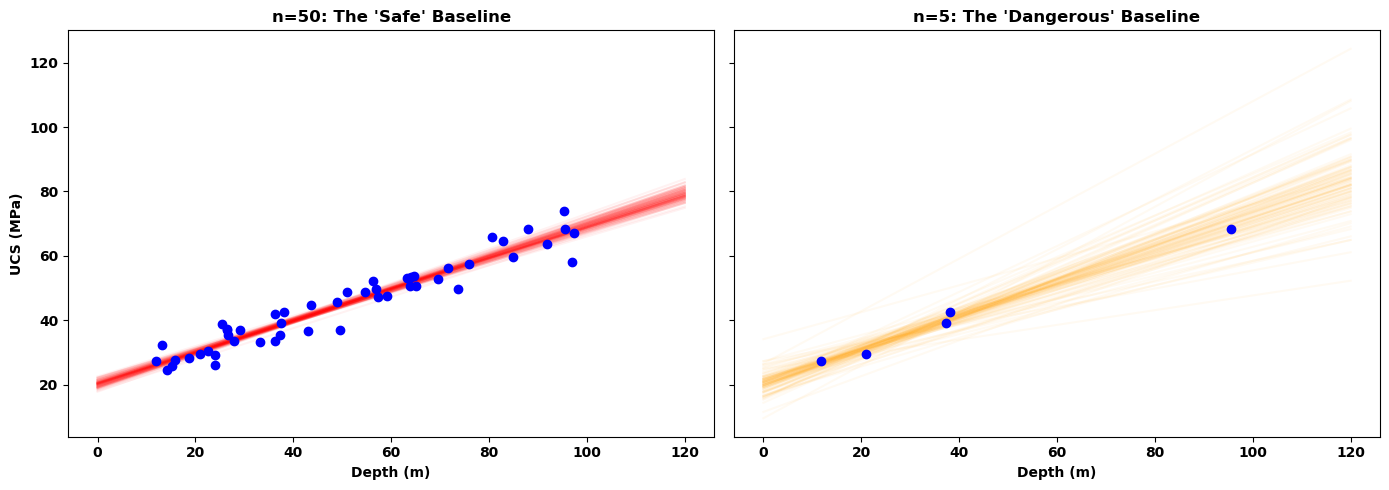

In [10]:
# comparisoin of posterrior regr lines distro for diff n

sparse_idx = np.random.choice(n, size=5, replace=False)
depth_sparse = depth[sparse_idx]
ucs_sparse = ucs[sparse_idx]

with pm.Model() as sparse_model:
    slope = pm.HalfNormal("slope", sigma=1)
    intercept = pm.Lognormal("intercept", mu=np.log(25), sigma=0.55)
    sigma = pm.HalfNormal("sigma", sigma=0.5)

    exp_ucs = pm.Deterministic("exp_ucs", intercept + slope * depth_sparse)
    y = pm.Lognormal("y", mu=pm.math.log(exp_ucs), sigma=sigma, observed=ucs_sparse)

    trace_sparse = pm.sample(2000, tune=1000, chains=2, cores=2, random_seed=42, progressbar=False)

# Visual Comparison: n=50 (Rich Data) vs n=5 (Sparse Data)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
x_plot = np.linspace(0, 120, 100)

# Left Plot: Full Data (n=50)
axes[0].scatter(depth, ucs, c='blue', zorder=5)
for i in range(100):
    s, ic = post_slopes[i*40], post_intercepts[i*40]
    axes[0].plot(x_plot, ic + s * x_plot, 'red', alpha=0.05)
axes[0].set_title(f"n=50: The 'Safe' Baseline")
axes[0].set_xlabel("Depth (m)")
axes[0].set_ylabel("UCS (MPa)")

# Right Plot: Sparse Data (n=5)
# Extract posterior samples from the sparse model
sparse_slopes = trace_sparse.posterior["slope"].values.flatten()
sparse_intercepts = trace_sparse.posterior["intercept"].values.flatten()

axes[1].scatter(depth_sparse, ucs_sparse, c='blue', zorder=5)
for i in range(100):
    s, ic = sparse_slopes[i*40], sparse_intercepts[i*40]
    axes[1].plot(x_plot, ic + s * x_plot, 'orange', alpha=0.05)
axes[1].set_title(f"n=5: The 'Dangerous' Baseline")
axes[1].set_xlabel("Depth (m)")

plt.tight_layout()
plt.show()

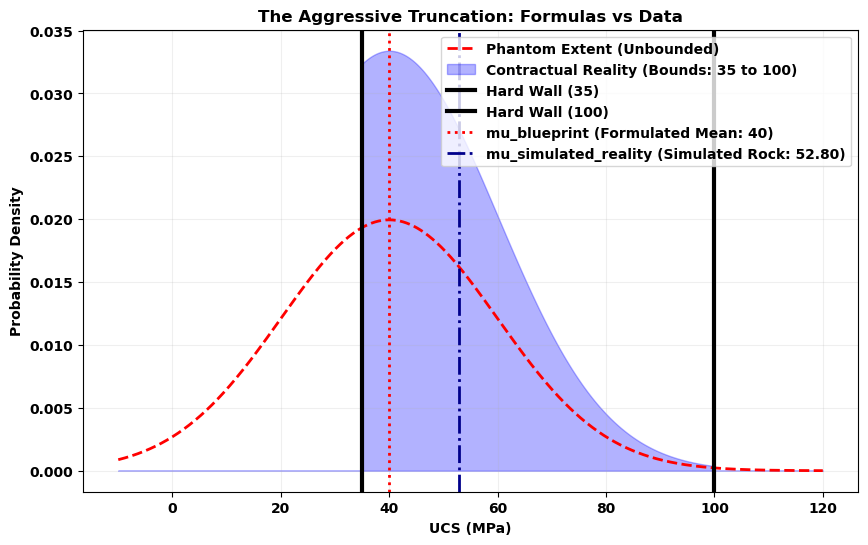

In [ ]:
# Scientific Intent: Visualizing the Aggressive Truncation Reality Shift
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, truncnorm

mu_blueprint = 40
sigma_blueprint = 20
lower_contract_limit = 35
upper_contract_limit = 100

# Generate the x-axis
x = np.linspace(-10, 120, 1000)

# 1. The Phantom Normal (Unbounded Geometry)
pdf_normal = norm.pdf(x, loc=mu_blueprint, scale=sigma_blueprint)

# 2. The Truncated Normal (Contractual Reality)
# Scipy requires bounds to be standardized (z-scores)
a = (lower_contract_limit - mu_blueprint) / sigma_blueprint
b = (upper_contract_limit - mu_blueprint) / sigma_blueprint
pdf_trunc = truncnorm.pdf(x, a, b, loc=mu_blueprint, scale=sigma_blueprint)

# Calculating the actual statistical mean of the surviving data
mu_simulated_reality = truncnorm.mean(a, b, loc=mu_blueprint, scale=sigma_blueprint)

plt.figure(figsize=(10, 6))

# Plotting the Distributions
plt.plot(x, pdf_normal, 'r--', lw=2, label=f'Phantom Extent (Unbounded)')
plt.fill_between(x, pdf_trunc, color='blue', alpha=0.3, label=f'Contractual Reality (Bounds: {lower_contract_limit} to {upper_contract_limit})')

# Erecting the Hard Walls
plt.axvline(lower_contract_limit, color='black', lw=3, label=f'Hard Wall ({lower_contract_limit})')
plt.axvline(upper_contract_limit, color='black', lw=3, label=f'Hard Wall ({upper_contract_limit})')

# The Proof of the Mean Shift
plt.axvline(mu_blueprint, color='red', linestyle=':', lw=2, label=f'mu_blueprint (Formulated Mean: {mu_blueprint})')
plt.axvline(mu_simulated_reality, color='darkblue', linestyle='-.', lw=2, label=f'mu_simulated_reality (Simulated Rock: {mu_simulated_reality:.2f})')

plt.title("The Aggressive Truncation: Formulas vs Data")
plt.xlabel("UCS (MPa)")
plt.ylabel("Probability Density")
plt.legend(loc='upper right')
plt.grid(alpha=0.2)
plt.show()